In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import numpy as np
import json

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import LogLocator
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter

from pathlib import Path

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config, generate_config_seq
from utils.interpolator import OpenMCTallyGridSurrogate

from coupled.vapour_reactor import VapourReactor
from coupled.iso_reactor import Reactor

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30


In [3]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)
    data["Reactor"]["power"]["thermal"] = 14.5784e6
    data["HeatPipe"]["material"]["h_cond"] = 691.5480

In [4]:
# Ns = [30, 30, 60]
Ns = [15, 15, 60]
Ns_coarse = [15, 15, 30]
cfg = generate_config(data, *Ns)
cfg_coarse = generate_config(data, *Ns_coarse)

iso_reactor        = Reactor(cfg)
vap_reactor        = VapourReactor(cfg)
vap_reactor_coarse = VapourReactor(cfg_coarse)
vap_reactor_full   = VapourReactor(cfg)

vap_reactor.heatpipe.solid.k_temperature = 1100

static_T = 1100
iso_reactor.set_variable_neutron_data(False, static_T)
vap_reactor.set_variable_neutron_data(False, static_T)
vap_reactor_coarse.set_variable_k(False)
vap_reactor_coarse.set_variable_neutron_data(False)
vap_reactor_full.set_variable_k(True)
vap_reactor_full.set_variable_neutron_data(True)

solver_iso      = Solver([iso_reactor])
solver_vap      = Solver([vap_reactor_coarse, vap_reactor], iterate = True)
solver_vap_full = Solver([vap_reactor_coarse, vap_reactor_full], iterate = True)
solver_iso.fsolve()
solver_vap.fsolve()
solver_vap_full.fsolve()

Mesh warning: N_Z changed from 60 to 69
Mesh warning: Fuel pin N_Z changed from 27 to 45
Mesh warning: Neutronics N_Z changed from 27 to 45
Mesh warning: N_Z changed from 30 to 23
Mesh warning: Fuel pin N_Z changed from 13 to 15
Mesh warning: Neutronics N_Z changed from 13 to 15
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolve message: The solution converged.
Running iteration 1 ...
fsolve message: The solution converged.
Running iteration 2 ...
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolve message: The solution converged.
Running iteration 1 ...
fsolve message: The solution converged.
Running iteration 2 ...
fsolve message: The solution converged.


In [5]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "cm",
    "font.size": 30,
    "text.latex.preamble": r"""
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{siunitx}
        \usepackage{bm}
    """
})

colors = {
    "black": "#000000",
    "blue": "#0072B2",
    "cyan": "#56B4E9",
    "green": "#009E73",
    "orange": "#E69F00",
    "red": "#D55E00",
    "magenta": "#CC79A7",
    "yellow": "#F0E442"
}

cmap_orange = LinearSegmentedColormap.from_list(
    "blue_to_white",
    [colors["orange"], "white"]
)


In [6]:
(T_hp_iso, T_FP_iso, (phi_n_g_iso, k_iso)) = solver_iso.solutions[0]
((T_solid_vap, u_v, T_v), T_FP_vap, (phi_n_g_vap, k_vap)) = solver_vap.solutions[1]
((T_solid_vap_full, u_v_full, T_v_full), T_FP_vap_full, (phi_n_g_vap_full, k_vap_full)) = solver_vap_full.solutions[1]

z_hp = iso_reactor.heat_pipe_thermal_model.Z
z_fp = np.linspace(0, cfg.FP.geometry.l, cfg.FP.mesh.N_Z)

print(np.mean(T_solid_vap_full))

957.9730935169706


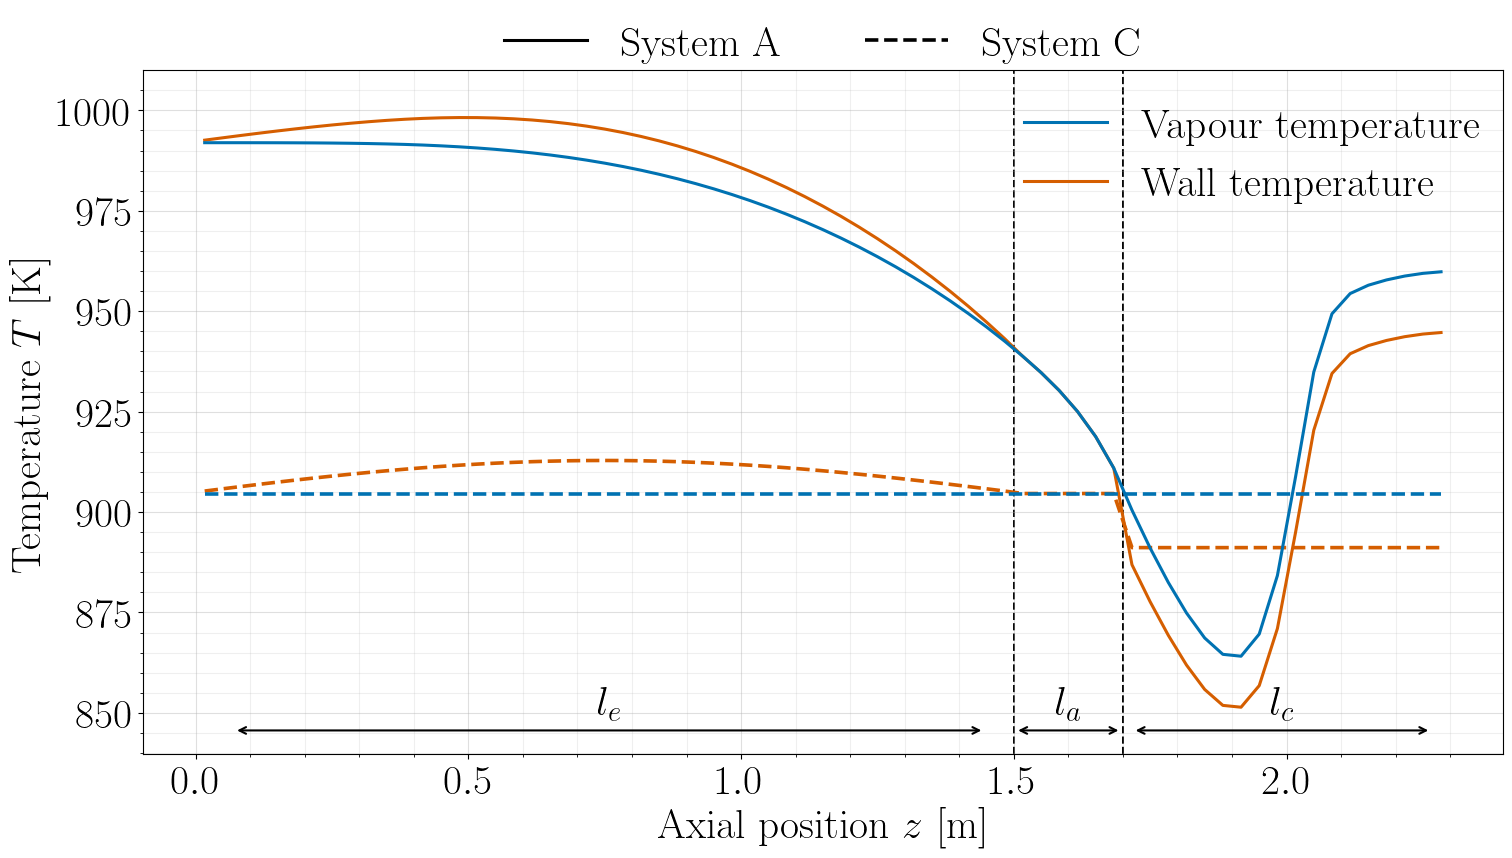

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

def add_axial_region_arrows(
    ax,
    z_bounds,
    labels=(r"$l_e$", r"$l_a$", r"$l_c$"),
    fontsize=30,
    y_arrow_frac=0.035,
    y_text_frac=0.047,
    shrink=0.04,
    arrow_lw=1.5,
):
    ymin, ymax = ax.get_ylim()

    y_arrow = ymin + y_arrow_frac * (ymax - ymin)
    y_text  = ymin + y_text_frac  * (ymax - ymin)

    for z0, z1, label in zip(z_bounds[:-1], z_bounds[1:], labels):
        dz = z1 - z0

        x0 = z0 + shrink * dz
        x1 = z1 - shrink * dz
        xc = 0.5 * (z0 + z1)

        ax.annotate(
            "",
            xy=(x1, y_arrow),
            xytext=(x0, y_arrow),
            arrowprops=dict(
                arrowstyle="<->",
                color="black",
                lw=arrow_lw,
                shrinkA=0,
                shrinkB=0,
                mutation_scale=12,
            ),
            zorder=10,
        )

        ax.text(
            xc,
            y_text,
            label,
            ha="center",
            va="bottom",
            fontsize=fontsize,
            color="black",
            zorder=10,
        )


# ---------------------------------------------------------------------
# Extract wall and vapour temperatures
# ---------------------------------------------------------------------

wall_slice = slice(
    cfg.HP.mesh.N_R - cfg.HP.mesh.N_wall,
    cfg.HP.mesh.N_R,
)

# Full reactor
T_wall_full = np.mean(T_solid_vap_full[:, wall_slice], axis=1)
T_vap_full = T_v_full

# Isothermal-vapour reactor
T_wall_iso = np.mean(T_hp_iso[0][:, wall_slice], axis=1)
T_vap_iso = np.full_like(z_hp, T_hp_iso[-1], dtype=float)


# ---------------------------------------------------------------------
# Plot setup
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 9))

quantity_colors = {
    "vapour": colors["blue"],
    "wall": colors["red"],
}

lw_full = 2.2
lw_iso = 2.6


# ---------------------------------------------------------------------
# Plot full reactor
# ---------------------------------------------------------------------

ax.plot(
    z_hp,
    T_vap_full,
    color=quantity_colors["vapour"],
    lw=lw_full,
    linestyle="-",
    zorder=4,
)

ax.plot(
    z_hp,
    T_wall_full,
    color=quantity_colors["wall"],
    lw=lw_full,
    linestyle="-",
    zorder=3,
)


# ---------------------------------------------------------------------
# Plot isothermal-vapour reactor
# ---------------------------------------------------------------------

ax.plot(
    z_hp,
    T_vap_iso,
    color=quantity_colors["vapour"],
    lw=lw_iso,
    linestyle="--",
    zorder=4,
)

ax.plot(
    z_hp,
    T_wall_iso,
    color=quantity_colors["wall"],
    lw=lw_iso,
    linestyle="--",
    zorder=3,
)


# ---------------------------------------------------------------------
# Axial region markers
# ---------------------------------------------------------------------

z_evap = cfg.HP.geometry.l_evap
z_adiabatic = cfg.HP.geometry.l_evap + cfg.HP.geometry.l_adiabatic

ymin = min(
    np.min(T_vap_full),
    np.min(T_wall_full),
    np.min(T_vap_iso),
    np.min(T_wall_iso),
)

ymax = max(
    np.max(T_vap_full),
    np.max(T_wall_full),
    np.max(T_vap_iso),
    np.max(T_wall_iso),
)

padding = 0.08 * (ymax - ymin)

ax.set_ylim(ymin - padding, ymax + padding)

ax.vlines(
    (z_evap, z_adiabatic),
    ymin - padding,
    ymax + padding,
    colors="black",
    linestyles="--",
    linewidth=1.4,
    zorder=0,
)

z_bounds = (
    np.min(z_hp),
    z_evap,
    z_adiabatic,
    np.max(z_hp),
)

add_axial_region_arrows(
    ax,
    z_bounds,
    labels=(r"$l_e$", r"$l_a$", r"$l_c$"),
    fontsize=30,
    y_arrow_frac=0.035,
    y_text_frac=0.047,
)


# ---------------------------------------------------------------------
# Axes formatting
# ---------------------------------------------------------------------

ax.set_xlabel(r"Axial position $z$ [$\si{\meter}$]", fontsize=30)
ax.set_ylabel(r"Temperature $T$ [$\si{\kelvin}$]", fontsize=30)

ax.minorticks_on()

ax.grid(which="major", alpha=0.4)
ax.grid(which="minor", alpha=0.2)

ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.tick_params(axis="both", labelsize=30)


# ---------------------------------------------------------------------
# Legends
# ---------------------------------------------------------------------

quantity_handles = [
    Line2D(
        [0], [0],
        color=quantity_colors["vapour"],
        lw=lw_full,
        linestyle="-",
        label="Vapour temperature",
    ),
    Line2D(
        [0], [0],
        color=quantity_colors["wall"],
        lw=lw_full,
        linestyle="-",
        label="Wall temperature",
    ),
]

system_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=lw_full,
        linestyle="-",
        label="System A",
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=lw_iso,
        linestyle="--",
        label="System C",
    ),
]

legend1 = ax.legend(
    handles=quantity_handles,
    loc="upper right",
    bbox_to_anchor=(1.01, 1.0),
    frameon=False,
    fontsize=30,
)

ax.add_artist(legend1)

ax.legend(
    handles=system_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=False,
    fontsize=30,
)


# ---------------------------------------------------------------------
# Save/show
# ---------------------------------------------------------------------

fig.subplots_adjust(
    bottom=0.24,
    left=0.13,
    right=0.98,
    top=1,
)

# plt.savefig(
#     "./outputs/report_figures/reactor_results/axial_heatpipe2.pdf",
#     bbox_inches="tight",
# )

plt.show()

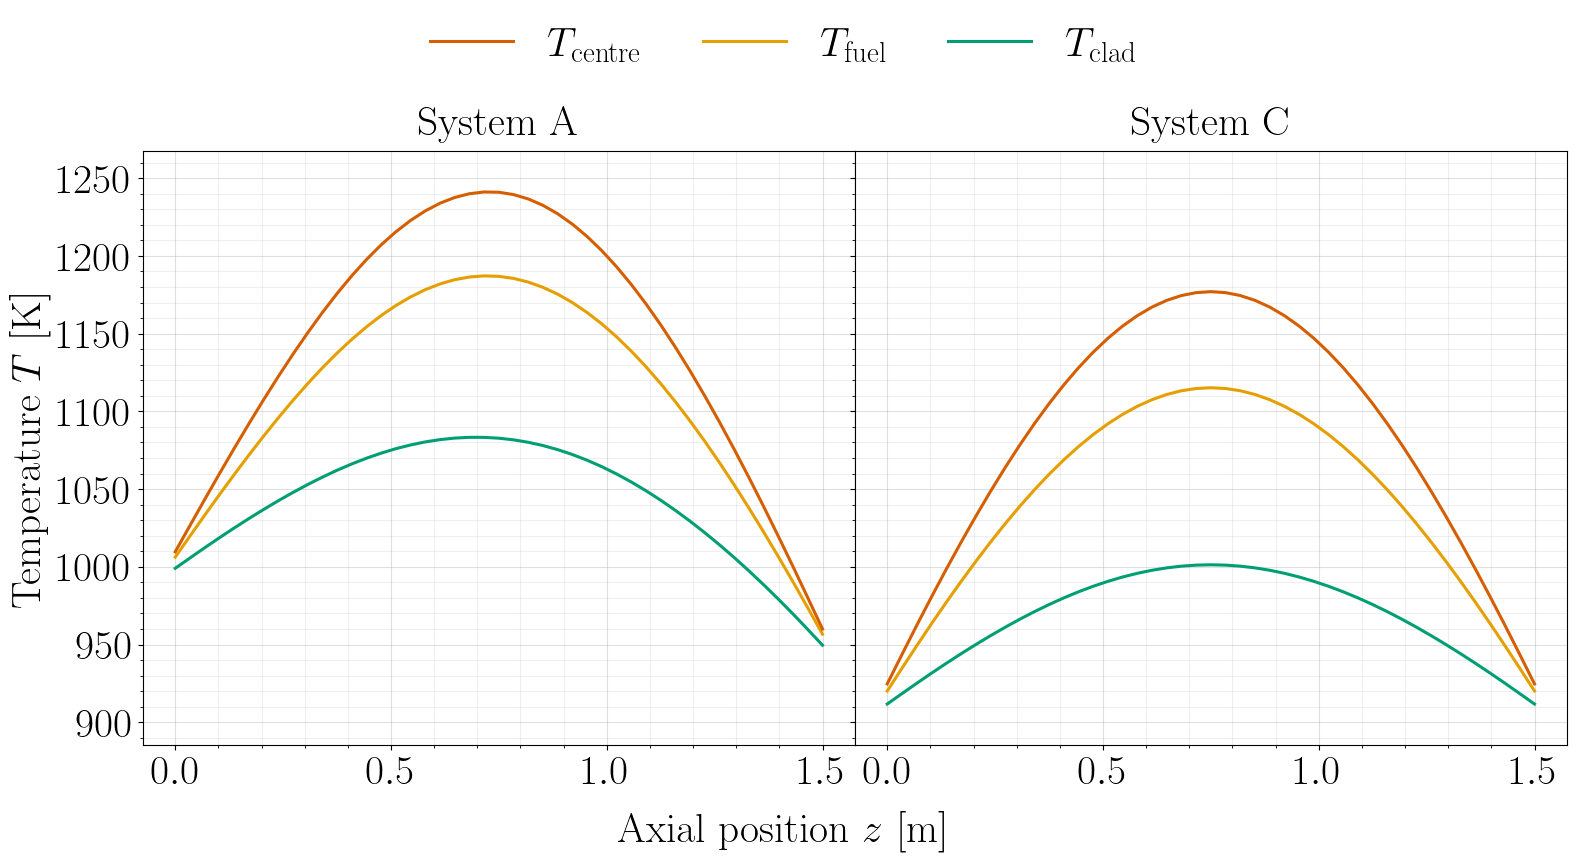

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D


# ---------------------------------------------------------------------
# Extract fuel-pin temperatures
# ---------------------------------------------------------------------

fuel_slice = slice(0, cfg.FP.mesh.N_fuel)
gap_slice  = slice(cfg.FP.mesh.N_fuel, cfg.FP.mesh.N_fuel + cfg.FP.mesh.N_gap)
clad_slice = slice(cfg.FP.mesh.N_fuel + cfg.FP.mesh.N_gap, cfg.FP.mesh.N_R)

# Full reactor
T_fuel_avg_full = np.mean(T_FP_vap_full[:, fuel_slice], axis=1)
T_clad_avg_full = np.mean(T_FP_vap_full[:, clad_slice], axis=1)

i_max_full = np.unravel_index(
    np.argmax(T_FP_vap_full),
    T_FP_vap_full.shape,
)[1]

T_max_slice_full = T_FP_vap_full[:, i_max_full]

# Isothermal-vapour reactor
T_fuel_avg_iso = np.mean(T_FP_iso[:, fuel_slice], axis=1)
T_clad_avg_iso = np.mean(T_FP_iso[:, clad_slice], axis=1)

i_max_iso = np.unravel_index(
    np.argmax(T_FP_iso),
    T_FP_iso.shape,
)[1]

T_max_slice_iso = T_FP_iso[:, i_max_iso]


# ---------------------------------------------------------------------
# Plot setup
# ---------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(16, 9),
    sharey=True,
    gridspec_kw={"wspace": 0.0},
)

quantity_colors = {
    "clad": colors["green"],
    "fuel": colors["orange"],
    "centre":  colors["red"],
}

lw = 2.2


# ---------------------------------------------------------------------
# Plot full reactor
# ---------------------------------------------------------------------

ax1.plot(
    z_fp,
    T_max_slice_full,
    color=quantity_colors["centre"],
    lw=lw,
    linestyle="-",
    zorder=4,
)

ax1.plot(
    z_fp,
    T_fuel_avg_full,
    color=quantity_colors["fuel"],
    lw=lw,
    linestyle="-",
    zorder=3,
)

ax1.plot(
    z_fp,
    T_clad_avg_full,
    color=quantity_colors["clad"],
    lw=lw,
    linestyle="-",
    zorder=2,
)


# ---------------------------------------------------------------------
# Plot isothermal-vapour reactor
# ---------------------------------------------------------------------

ax2.plot(
    z_fp,
    T_max_slice_iso,
    color=quantity_colors["centre"],
    lw=lw,
    linestyle="-",
    zorder=4,
)

ax2.plot(
    z_fp,
    T_fuel_avg_iso,
    color=quantity_colors["fuel"],
    lw=lw,
    linestyle="-",
    zorder=3,
)

ax2.plot(
    z_fp,
    T_clad_avg_iso,
    color=quantity_colors["clad"],
    lw=lw,
    linestyle="-",
    zorder=2,
)


# ---------------------------------------------------------------------
# Titles
# ---------------------------------------------------------------------

ax1.set_title("System A", fontsize=30, pad=12)
ax2.set_title("System C", fontsize=30, pad=12)


# ---------------------------------------------------------------------
# Axes formatting
# ---------------------------------------------------------------------

ax1.set_ylabel(r"Temperature $T$ [$\si{\kelvin}$]", fontsize=30)
fig.supxlabel(r"Axial position $z$ [$\si{\meter}$]", fontsize=30, y=0.04)

for ax in (ax1, ax2):
    ax.minorticks_on()
    ax.grid(which="major", alpha=0.4)
    ax.grid(which="minor", alpha=0.2)

    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_major_locator(MultipleLocator(50))

    ax.tick_params(axis="both", labelsize=30)

# Hide y tick labels on right subplot, but keep ticks/grid
ax2.tick_params(axis="y", labelleft=False)


# ---------------------------------------------------------------------
# Optional shared y-limits
# ---------------------------------------------------------------------

all_temperatures = np.concatenate([
    T_max_slice_full,
    T_fuel_avg_full,
    T_clad_avg_full,
    T_max_slice_iso,
    T_fuel_avg_iso,
    T_clad_avg_iso,
])

ymin = np.min(all_temperatures)
ymax = np.max(all_temperatures)
padding = 0.08 * (ymax - ymin)

ax1.set_ylim(ymin - padding, ymax + padding)


# ---------------------------------------------------------------------
# Legend
# ---------------------------------------------------------------------

color_handles = [
    Line2D(
        [0], [0],
        color=quantity_colors["centre"],
        lw=lw,
        linestyle="-",
        label=r"$T_\text{centre}$",
    ),
    Line2D(
        [0], [0],
        color=quantity_colors["fuel"],
        lw=lw,
        linestyle="-",
        label=r"$T_\text{fuel}$",
    ),
    Line2D(
        [0], [0],
        color=quantity_colors["clad"],
        lw=lw,
        linestyle="-",
        label=r"$T_\text{clad}$",
    ),
]

fig.legend(
    handles=color_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.00),
    ncol=3,
    frameon=False,
    fontsize=30,
    columnspacing=1.5,
    handlelength=2.0,
)


# ---------------------------------------------------------------------
# Layout and save/show
# ---------------------------------------------------------------------

fig.subplots_adjust(
    top=0.82,
    bottom=0.16,
    left=0.10,
    right=0.99,
    wspace=0.0,
)

# plt.savefig(
#     r"./outputs/report_figures/reactor_results/axial_fuelpin2.pdf",
#     bbox_inches="tight",
# )

plt.show()

In [9]:
import numpy as np

# ---------------------------------------------------------------------
# Collect systems
# ---------------------------------------------------------------------

systems_T = {
    "A": {
        "T": T_FP_vap_full,
        "z": z_fp,
    },
    "B": {
        "T": T_FP_vap,
        "z": z_fp,
    },
    "C": {
        "T": T_FP_iso,
        "z": z_fp,
    },
}

# ---------------------------------------------------------------------
# Column mapping
# ---------------------------------------------------------------------
# Adjust these if your T_FP array uses a different ordering.

idx_max = 0
idx_fuel = 1
idx_clad = 2

# If temperatures are stored in Kelvin, set this to True.
# If they are already in Celsius, set it to False.

CONVERT_K_TO_C = True

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def to_celsius(T):
    T = np.asarray(T)
    return T - 273.15 if CONVERT_K_TO_C else T


def compute_temperature_quantities(T_FP, z):
    T_FP = to_celsius(T_FP)
    z = np.asarray(z)

    T_max = T_FP[:, idx_max]
    T_fuel = T_FP[:, idx_fuel]
    T_clad = T_FP[:, idx_clad]

    return {
        "Tmax_max": np.max(T_max),
        "Tfuel_max": np.max(T_fuel),
        "Tclad_max": np.max(T_clad),

        "Tmax_avg": np.trapezoid(T_max, z) / (z[-1] - z[0]),
        "Tfuel_avg": np.trapezoid(T_fuel, z) / (z[-1] - z[0]),
        "Tclad_avg": np.trapezoid(T_clad, z) / (z[-1] - z[0]),

        "Tmax_min": np.min(T_max),
        "Tfuel_min": np.min(T_fuel),
        "Tclad_min": np.min(T_clad),

        "Delta_fuel_clad_max": np.max(T_fuel - T_clad),
        "Delta_max_clad_max": np.max(T_max - T_clad),
        "Delta_max_fuel_max": np.max(T_max - T_fuel),
    }


results_T = {}

for name, data in systems_T.items():
    results_T[name] = compute_temperature_quantities(data["T"], data["z"])

# ---------------------------------------------------------------------
# Print compact vertically stacked LaTeX table
# ---------------------------------------------------------------------

rows = [
    (r"$T_\text{max,max}$", "Tmax_max"),
    (r"$T_\text{fuel,max}$", "Tfuel_max"),
    (r"$T_\text{clad,max}$", "Tclad_max"),
    (r"$\bar{T}_\text{max}$", "Tmax_avg"),
    (r"$\bar{T}_\text{fuel}$", "Tfuel_avg"),
    (r"$\bar{T}_\text{clad}$", "Tclad_avg"),
    (r"$\max_z(T_\text{fuel}-T_\text{clad})$", "Delta_fuel_clad_max"),
    (r"$\max_z(T_\text{max}-T_\text{clad})$", "Delta_max_clad_max"),
]

print(r"\begin{tabular}{lc}")
print(r"    \hline")
print(r"    \textbf{Quantity} & \textbf{Value} \\")
print(r"    \hline")

for system_name in ["A", "B", "C"]:
    print()
    print(rf"    \multicolumn{{2}}{{l}}{{\textbf{{System {system_name}}}}} \\")

    for label, key in rows:
        value = results_T[system_name][key]
        print(rf"    {label} & {value:.2f} \\")

    print(r"    \hline")

print(r"\end{tabular}")

\begin{tabular}{lc}
    \hline
    \textbf{Quantity} & \textbf{Value} \\
    \hline

    \multicolumn{2}{l}{\textbf{System A}} \\
    $T_\text{max,max}$ & 967.99 \\
    $T_\text{fuel,max}$ & 957.67 \\
    $T_\text{clad,max}$ & 947.70 \\
    $\bar{T}_\text{max}$ & 874.69 \\
    $\bar{T}_\text{fuel}$ & 868.05 \\
    $\bar{T}_\text{clad}$ & 861.62 \\
    $\max_z(T_\text{fuel}-T_\text{clad})$ & 9.99 \\
    $\max_z(T_\text{max}-T_\text{clad})$ & 20.34 \\
    \hline

    \multicolumn{2}{l}{\textbf{System B}} \\
    $T_\text{max,max}$ & 988.13 \\
    $T_\text{fuel,max}$ & 976.62 \\
    $T_\text{clad,max}$ & 965.40 \\
    $\bar{T}_\text{max}$ & 890.97 \\
    $\bar{T}_\text{fuel}$ & 883.26 \\
    $\bar{T}_\text{clad}$ & 875.75 \\
    $\max_z(T_\text{fuel}-T_\text{clad})$ & 11.24 \\
    $\max_z(T_\text{max}-T_\text{clad})$ & 22.78 \\
    \hline

    \multicolumn{2}{l}{\textbf{System C}} \\
    $T_\text{max,max}$ & 903.86 \\
    $T_\text{fuel,max}$ & 892.32 \\
    $T_\text{clad,max}$ & 881.08 \\


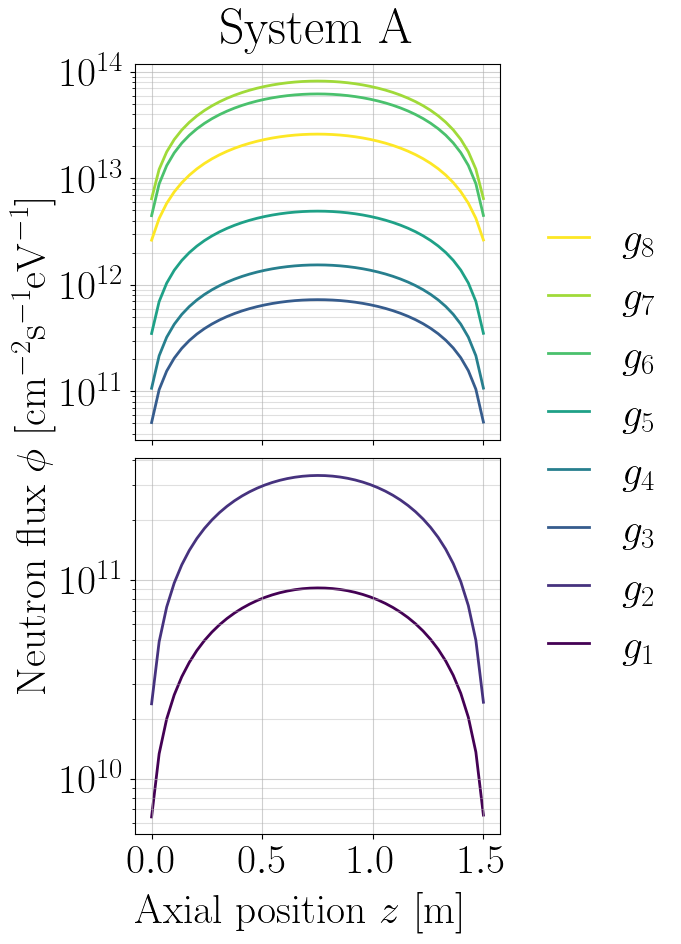

In [10]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, LogLocator, LogFormatterMathtext, NullFormatter
import numpy as np
import matplotlib.pyplot as plt

def add_free_text(ax, text, x=0.5, y=0.05, fontsize=22):
    ax.text(
        x, y,
        text,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=fontsize,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
        ),
        zorder=20,
    )

fig, axes = plt.subplots(
    2, 1,
    figsize=(5, 10),
    sharex=True,
    gridspec_kw={
        "hspace": 0.05,
    }
)

ax1, ax4 = axes

N_G = phi_n_g_vap_full.shape[1]

cmap = plt.get_cmap("viridis")
colors_cmap = cmap(np.linspace(0, 1, N_G)[::-1])

# Top row: all groups except the two lowest-flux ones
top_indices = range(0, max(N_G - 2, 0))

# Bottom row: the two lowest-flux groups
bottom_indices = range(max(N_G - 2, 0), N_G)

# Top plot
for i in top_indices:
    ax1.plot(
        z_fp,
        1e-4 * phi_n_g_vap_full[:, i],
        color=colors_cmap[i],
        lw=2,
        linestyle="-",
        zorder=8 - i,
    )

# Bottom plot
for i in bottom_indices:
    ax4.plot(
        z_fp,
        1e-4 * phi_n_g_vap_full[:, i],
        color=colors_cmap[i],
        lw=2,
        linestyle="-",
        zorder=8 - i,
    )

# Common formatting
for ax in axes:
    ax.set_yscale("log")

    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))

    ax.yaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100)
    )
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.xaxis.set_major_locator(MultipleLocator(0.5))

    ax.grid(which="major", alpha=0.6)
    ax.grid(which="minor", alpha=0.4)

# Y-limits
# ax1.set_ylim((4e15 * 1e-4, 1e18 * 1e-4))
# ax4.set_ylim((5e9 * 1e-4, 5e14 * 1e-4))

# Title
ax1.set_title("System A", pad=14)

# Free text in upper plot
# add_free_text(
#     ax1,
#     r"$k_\text{eff} = $" + f"{k_vap_full:.4f}",
#     x=0.5,
#     y=0.05,
# )

# Axis labels
units = r"\si{\centi\meter^{-2}\second^{-1}\electronvolt^{-1}}"

fig.supylabel(rf"Neutron flux $\phi$ [{units}]", fontsize=30)
fig.supxlabel(r"Axial position $z$ [$\si{\meter}$]", fontsize=30, x=0.6)

# Hide x tick labels on top plot
ax1.tick_params(axis="x", labelbottom=False)

# Description box in bottom plot
# add_model_textbox(
#     ax4,
#     "Discretised $T_\\mathrm{vap}$\nVariable $k_\\mathrm{cond}$\nVariable neutron data",
#     y=0.255,
#     x=0.25,
# )

# Legend: all plotted groups
color_handles = [
    Line2D([0], [0], color=colors_cmap[i], lw=2, linestyle="-", label=rf"$g_{8 - i}$")
    for i in range(N_G)
]

fig.legend(
    handles=color_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=False,
    handlelength=1,
)

fig.subplots_adjust(
    top=0.88,
    bottom=0.11,
    left=0.27,
    right=1,
)

# plt.savefig(r"./outputs/report_figures/reactor_results/axial_neutron.pdf", bbox_inches="tight")
plt.show()

In [11]:
# ---------------------------------------------------------------------
# Collect systems
# ---------------------------------------------------------------------

systems = {
    "A": {
        "phi": phi_n_g_vap_full,
        "k": k_vap_full,
        "z": z_fp,
    },
    "B": {
        "phi": phi_n_g_vap,
        "k": k_vap,
        "z": z_fp,
    },
    "C": {
        "phi": phi_n_g_iso,
        "k": k_iso,
        "z": z_fp,
    },
}

# If your neutron-flux grid is actually z_hp rather than z_fp, change "z": z_fp to "z": z_hp above.

# ---------------------------------------------------------------------
# Choose group ranges
# ---------------------------------------------------------------------
# Assumption: g1 is highest energy and g8 is lowest energy.
# Adjust these if your group ordering is different.

fast_groups = [0, 1, 2, 3]       # g1--g4
thermal_groups = [6, 7]          # g7--g8

# ---------------------------------------------------------------------
# Unit conversion
# ---------------------------------------------------------------------
# Your stored phi is in m^-2 s^-1 eV^-1.
# For plotting/table values in cm^-2 s^-1 eV^-1, divide by 1e4.

USE_CM_UNITS = True

phi_factor = 1e-4 if USE_CM_UNITS else 1.0
flux_unit = r"\si{\centi\meter^{-2}\second^{-1}\electronvolt^{-1}}" if USE_CM_UNITS else r"\si{\meter^{-2}\second^{-1}\electronvolt^{-1}}"

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def sci_latex(x, sig=4):
    if x == 0:
        return "0"

    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / 10**exponent

    return rf"{mantissa:.{sig-1}f}\times 10^{{{exponent}}}"


def compute_flux_quantities(phi, z):
    phi = np.asarray(phi) * phi_factor
    z = np.asarray(z)

    phi_tot_z = np.sum(phi, axis=1)

    Phi_g = np.trapezoid(phi, z, axis=0)
    Phi_tot = np.sum(Phi_g)

    Phi_fast = np.sum(Phi_g[fast_groups])
    Phi_thermal = np.sum(Phi_g[thermal_groups])

    f_g = Phi_g / Phi_tot

    return {
        "Phi_g": Phi_g,
        "Phi_tot": Phi_tot,
        "Phi_fast": Phi_fast,
        "Phi_thermal": Phi_thermal,
        "fast_thermal_ratio": Phi_fast / Phi_thermal,
        "max_phi_tot": np.max(phi_tot_z),
        "avg_phi_tot": Phi_tot / (z[-1] - z[0]),
        "f_g": f_g,
    }


results = {}

for name, data in systems.items():
    results[name] = compute_flux_quantities(data["phi"], data["z"])
    results[name]["k"] = data["k"]

# ---------------------------------------------------------------------
# Compact comparison table
# ---------------------------------------------------------------------

rows = [
    (r"$k_\text{eff}$", "k", "{:.4f}"),
    (r"$\int_0^L \sum_g \phi_g\, dz$", "Phi_tot", sci_latex),
    (r"$\max_z \sum_g \phi_g$", "max_phi_tot", sci_latex),
    (r"$\langle \sum_g \phi_g \rangle_z$", "avg_phi_tot", sci_latex),
    (r"$\Phi_\text{fast}/\Phi_\text{thermal}$", "fast_thermal_ratio", "{:.4f}"),
]

print(r"\begin{tabular}{lccc}")
print(r"\hline")
print(r"\textbf{Quantity} & \textbf{A} & \textbf{B} & \textbf{C} \\")
print(r"\hline")

for label, key, fmt in rows:
    values = []
    for name in ["A", "B", "C"]:
        value = results[name][key]

        if isinstance(fmt, str):
            values.append(fmt.format(value))
        else:
            values.append(rf"${fmt(value)}$")

    print(label + " & " + " & ".join(values) + r" \\")

print(r"\hline")
print(r"\end{tabular}")

\begin{tabular}{lccc}
\hline
\textbf{Quantity} & \textbf{A} & \textbf{B} & \textbf{C} \\
\hline
$k_\text{eff}$ & 1.2042 & 1.2055 & 1.2055 \\
$\int_0^L \sum_g \phi_g\, dz$ & $1.791\times 10^{14}$ & $1.790\times 10^{14}$ & $1.790\times 10^{14}$ \\
$\max_z \sum_g \phi_g$ & $1.781\times 10^{14}$ & $1.784\times 10^{14}$ & $1.784\times 10^{14}$ \\
$\langle \sum_g \phi_g \rangle_z$ & $1.194\times 10^{14}$ & $1.194\times 10^{14}$ & $1.194\times 10^{14}$ \\
$\Phi_\text{fast}/\Phi_\text{thermal}$ & 406.3027 & 409.8403 & 409.8403 \\
\hline
\end{tabular}


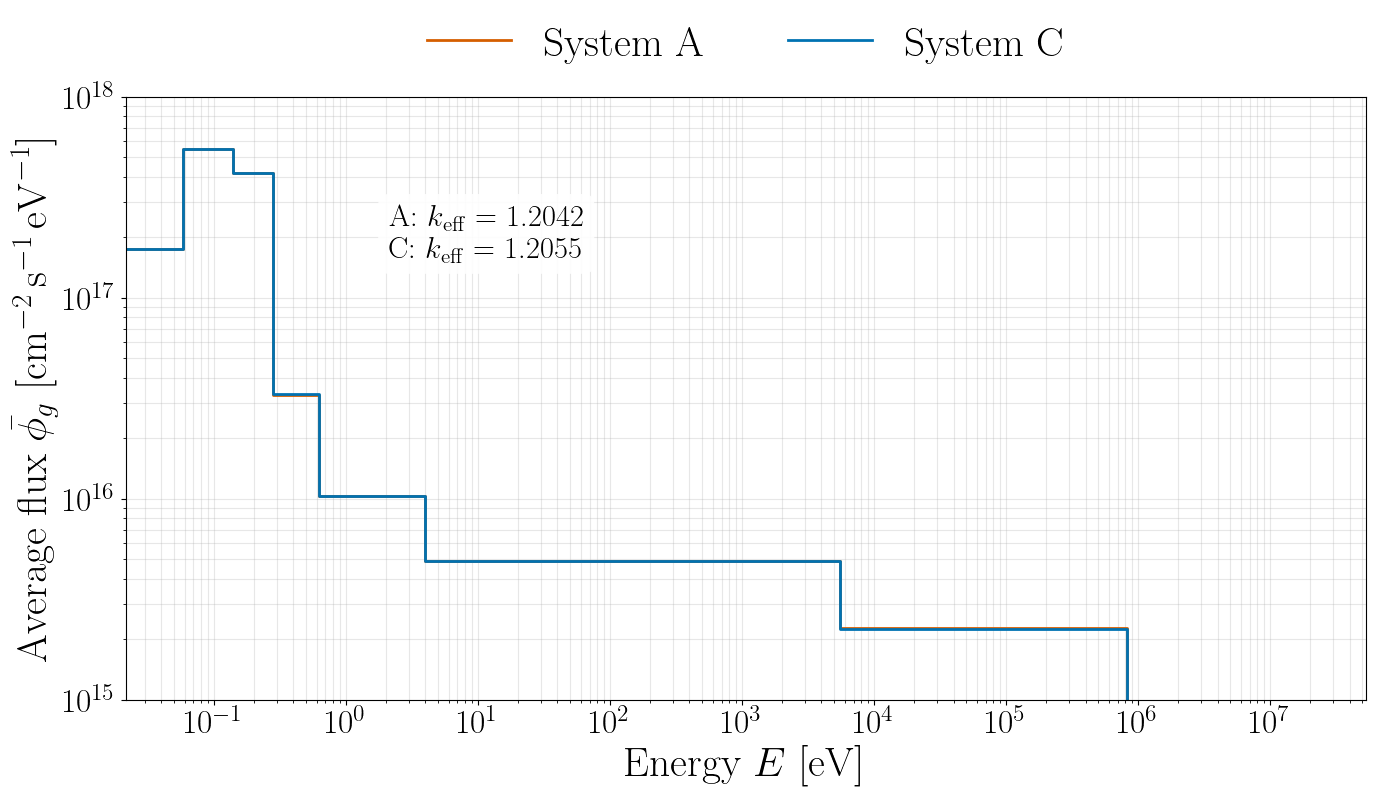

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# Dummy 8-group energy boundaries [eV]
energy_edges = np.array([
    0.0,
    5.80e-2,
    1.40e-1,
    2.80e-1,
    6.25e-1,
    4.00e0,
    5.53e3,
    8.21e5,
    2.00e7,
])

# Extract solutions
(T_hp_iso, T_FP_iso, (phi_n_g_iso, k_iso)) = solver_iso.solutions[0]

((T_solid_vap, u_v, T_v),
 T_FP_vap,
 (phi_n_g_vap, k_vap)) = solver_vap.solutions[1]

((T_solid_vap_full, u_v_full, T_v_full),
 T_FP_vap_full,
 (phi_n_g_vap_full, k_vap_full)) = solver_vap_full.solutions[1]

# Axial grids
z_hp = iso_reactor.heat_pipe_thermal_model.Z
z_fp = np.linspace(0, cfg.FP.geometry.l, cfg.FP.mesh.N_Z)

# Spatially integrated group fluxes
Phi_iso = np.trapezoid(phi_n_g_iso, z_fp, axis=0) / np.trapezoid(np.ones_like(phi_n_g_iso), z_fp, axis=0)
Phi_vap = np.trapezoid(phi_n_g_vap, z_fp, axis=0) / np.trapezoid(np.ones_like(phi_n_g_vap), z_fp, axis=0)
Phi_vap_full = np.trapezoid(phi_n_g_vap_full, z_fp, axis=0) / np.trapezoid(np.ones_like(phi_n_g_vap_full), z_fp, axis=0)

# For step plots, duplicate the group values so each group is constant
def group_step_values(values):
    return np.r_[values, values[-1]]

fig, ax = plt.subplots(figsize=(16, 9))

ax.step(
    energy_edges,
    group_step_values(Phi_vap_full),
    where="post",
    linewidth=2,
    label=r"System A",
    color=colors["red"]
)

ax.step(
    energy_edges,
    group_step_values(Phi_iso),
    where="post",
    linewidth=2,
    label=r"System C",
    color=colors["blue"]
)

ax.set_ylim((1e15, 1e18))

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Energy $E$ [eV]", fontsize=30)
ax.set_ylabel(r"Average flux $\bar{\phi_g}$ $[\si{\per\centi\meter\squared\per\second\per\electronvolt}]$", fontsize=30)

ax.tick_params(axis="both", labelsize=24)
ax.grid(True, which="both", alpha=0.3)

# Legend
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=2,
    frameon=False,
    fontsize=30
)

# Text box under the legend
fig.text(
    0.35,
    0.66,
    r"A: $k_\mathrm{eff}$ = " + f"{k_vap_full:.4f}" + "\n" + r"C: $k_\mathrm{eff}$ = " + f"{k_iso:.4f}",
    ha="center",
    va="top",
    fontsize=22,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="none",
        alpha=0.9,
    )
)

fig.subplots_adjust(top=0.78)

# plt.savefig("./outputs/report_figures/reactor_results/flux_vs_energy2.pdf", bbox_inches="tight")
plt.show()